# Evaluation des macro-domaines EDdA

Version 15 janvier 2026 intégrant les 40 domaines de Denis

In [1]:
import pandas as pd

In [2]:
#df_duflt = pd.read_csv("/Users/lmoncla/Nextcloud/Recherche/Projets/TREVOUX/Data/annotations/1743/Trevoux1743.tsv", sep="\t")

dirpath = "../data/EDdA/"

df_edda = pd.read_csv(dirpath+"EDdA_macrodomains.tsv", sep="\t")

In [3]:
df_edda.head()

,book,volume,numero,head,author,artfl_domain,text,predicted_label_id,predicted_label
0,EDdA,1,1,Title Page,unsigned,unclassified,"ENCYCLOPÉDIE, DICTIONNAIRE RAISONNÉ DES SCIENC...",12,Grammaire
1,EDdA,1,2,A MONSEIGNEUR LE COMTE D'ARGENSON,Diderot & d'Alembert,unclassified,"A MONSEIGNEUR LE COMTE D'ARGENSON, MINISTRE ET...",12,Grammaire
2,EDdA,1,3,DISCOURS PRÉLIMINAIRE DES EDITEURS,d'Alembert,unclassified,DISCOURS PRÉLIMINAIRE DES EDITEURS. L'Encyclop...,31,Métiers [papier]
3,EDdA,1,5,"A, a & a",Dumarsais5,Grammaire,"A, a & a s.m. (ordre Encyclopéd. Entend. Scien...",12,Grammaire
4,EDdA,1,6,A,Dumarsais5,unclassified,"A, mot, est 1. la troisieme personne du présen...",12,Grammaire


In [4]:
df_domaines_denis = pd.read_excel('Conversion_EDdA_protodesignants_MacroDomaines.xlsx')

df_domaines_denis.rename(columns={"normclass": "artfl_domain", "40 Super domain Modifié Denis": "denis_domain"}, inplace=True)
df_domaines_denis = df_domaines_denis[["artfl_domain", "denis_domain"]]
df_domaines_denis.head()

,artfl_domain,denis_domain
0,Jardinage,Agriculture - Économie rustique
1,Economie rustique,Agriculture - Économie rustique
2,Agriculture,Agriculture - Économie rustique
3,Raffinage de sucre,Agriculture - Économie rustique
4,Raffinerie,Agriculture - Économie rustique


In [5]:

df_domaines_denis.rename(columns={"denis_domain":"macro_domain"}, inplace=True)
df_domaines_denis.head()

,artfl_domain,macro_domain
0,Jardinage,Agriculture - Économie rustique
1,Economie rustique,Agriculture - Économie rustique
2,Agriculture,Agriculture - Économie rustique
3,Raffinage de sucre,Agriculture - Économie rustique
4,Raffinerie,Agriculture - Économie rustique


In [6]:
print(df_domaines_denis['macro_domain'].unique())
print(len(df_domaines_denis['macro_domain'].unique()))

['Agriculture - Économie rustique' 'Anatomie' 'Antiquité' 'Architecture'
 'Arts mécaniques - Manufactures' 'Beaux-arts' 'Belles-lettres'
 'Belles-Lettres' 'Blason' 'Chasse-pêche' 'Chimie' 'Commerce'
 'Droit Jurisprudence' 'Géographie' 'grammaire' 'Grammaire' 'Histoire'
 'Histoire ' 'Histoire naturelle' 'Jeu' 'Jeu ' 'Maréchalerie - Manège'
 'Marine' 'Mathématiques' 'médailles' 'Médailles' 'Médecine' 'Mesure'
 'Métiers [ métal, minéral,  dérivés]' 'Métiers [alimentation]'
 'Métiers [alimentation}' 'Métiers [autres]' 'Métier [autres]'
 'Métiers [bois]' 'Métiers [cuir, peaux]' 'Métiers [cuirs, peaux]'
 'Métiers [papier]' 'Métiers [tissu, habit]' 'métiers [tissu, habit]'
 ' Métiers [tissu, habit]' 'Militaire' 'Monnaie' 'Musique' 'Pharmacie'
 'Philosophie' 'Politique' 'Religion' 'Sciences physico-mathématiques'
 'supersitition' 'Superstition' '  Superstition' ' Superstition' 'Voyage'
 nan]
54


In [7]:
# trim spaces from df_domaines_denis['denis_domain']
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].str.strip()
# replace supersitition by Supersitition
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('supersitition', 'Superstition')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('Métiers [alimentation}', 'Métiers [alimentation]')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('grammaire', 'Grammaire')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('médailles', 'Médailles')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('métiers [tissu, habit]', 'Métiers [tissu, habit]')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('Belles-Lettres', 'Belles-lettres')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('Métier [autres]', 'Métiers [autres]')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('Métiers [ métal, minéral,  dérivés]', 'Métiers [métal, minéral, dérivés]')
df_domaines_denis['macro_domain'] = df_domaines_denis['macro_domain'].replace('Métiers [cuirs, peaux]', 'Métiers [cuir, peaux]')

df_domaines_denis = df_domaines_denis.dropna(subset=['macro_domain'])

In [8]:
print(df_domaines_denis['macro_domain'].unique())
print(len(df_domaines_denis['macro_domain'].unique()))

['Agriculture - Économie rustique' 'Anatomie' 'Antiquité' 'Architecture'
 'Arts mécaniques - Manufactures' 'Beaux-arts' 'Belles-lettres' 'Blason'
 'Chasse-pêche' 'Chimie' 'Commerce' 'Droit Jurisprudence' 'Géographie'
 'Grammaire' 'Histoire' 'Histoire naturelle' 'Jeu' 'Maréchalerie - Manège'
 'Marine' 'Mathématiques' 'Médailles' 'Médecine' 'Mesure'
 'Métiers [métal, minéral, dérivés]' 'Métiers [alimentation]'
 'Métiers [autres]' 'Métiers [bois]' 'Métiers [cuir, peaux]'
 'Métiers [papier]' 'Métiers [tissu, habit]' 'Militaire' 'Monnaie'
 'Musique' 'Pharmacie' 'Philosophie' 'Politique' 'Religion'
 'Sciences physico-mathématiques' 'Superstition' 'Voyage']
40


In [9]:
df = pd.merge(df_edda, df_domaines_denis, on='artfl_domain', how='left')
df.head()

,book,volume,numero,head,author,artfl_domain,text,predicted_label_id,predicted_label,macro_domain
0,EDdA,1,1,Title Page,unsigned,unclassified,"ENCYCLOPÉDIE, DICTIONNAIRE RAISONNÉ DES SCIENC...",12,Grammaire,NaN
1,EDdA,1,2,A MONSEIGNEUR LE COMTE D'ARGENSON,Diderot & d'Alembert,unclassified,"A MONSEIGNEUR LE COMTE D'ARGENSON, MINISTRE ET...",12,Grammaire,NaN
2,EDdA,1,3,DISCOURS PRÉLIMINAIRE DES EDITEURS,d'Alembert,unclassified,DISCOURS PRÉLIMINAIRE DES EDITEURS. L'Encyclop...,31,Métiers [papier],NaN
3,EDdA,1,5,"A, a & a",Dumarsais5,Grammaire,"A, a & a s.m. (ordre Encyclopéd. Entend. Scien...",12,Grammaire,Grammaire
4,EDdA,1,6,A,Dumarsais5,unclassified,"A, mot, est 1. la troisieme personne du présen...",12,Grammaire,NaN


In [10]:
# macro_domain not NaN
df[~df['macro_domain'].notna()]

,book,volume,numero,head,author,artfl_domain,text,predicted_label_id,predicted_label,macro_domain
0,EDdA,1,1,Title Page,unsigned,unclassified,"ENCYCLOPÉDIE, DICTIONNAIRE RAISONNÉ DES SCIENC...",12,Grammaire,NaN
1,EDdA,1,2,A MONSEIGNEUR LE COMTE D'ARGENSON,Diderot & d'Alembert,unclassified,"A MONSEIGNEUR LE COMTE D'ARGENSON, MINISTRE ET...",12,Grammaire,NaN
2,EDdA,1,3,DISCOURS PRÉLIMINAIRE DES EDITEURS,d'Alembert,unclassified,DISCOURS PRÉLIMINAIRE DES EDITEURS. L'Encyclop...,31,Métiers [papier],NaN
4,EDdA,1,6,A,Dumarsais5,unclassified,"A, mot, est 1. la troisieme personne du présen...",12,Grammaire,NaN
5,EDdA,1,7,A,Dumarsais,unclassified,"A, préposition vient du latin à, à dextris, à ...",12,Grammaire,NaN
...,...,...,...,...,...,...,...,...,...,...
71105,EDdA,17,3151,FARINE,Jaucourt,Economie,"FARINE, s. f. (Economie.) la farine d'Angleter...",0,Agriculture - Économie rustique,NaN
71111,EDdA,17,3157,FORTUNE,unsigned,Inscription | Médailles | Poésie,"FORTUNE, (Inscript. Médailles, Poésie.) les mé...",24,Médailles,NaN
71140,EDdA,17,3186,HÉRÉSIDES,unsigned,unclassified,"HÉRÉSIDES, s. f. plur. prêtresses de Junon à A...",2,Antiquité,NaN
71142,EDdA,17,3188,IDOLATRIE,unsigned,Philosophie | Théologie,"IDOLATRIE, s. f. (Philos. & Théolog.) l'idolat...",36,Religion,NaN


In [11]:
# drop column predicted_label_id
df = df.drop(columns=['predicted_label_id'])

<Axes: title={'center': 'Distribution of macro-domains in the dataset'}, xlabel='macro_domain'>

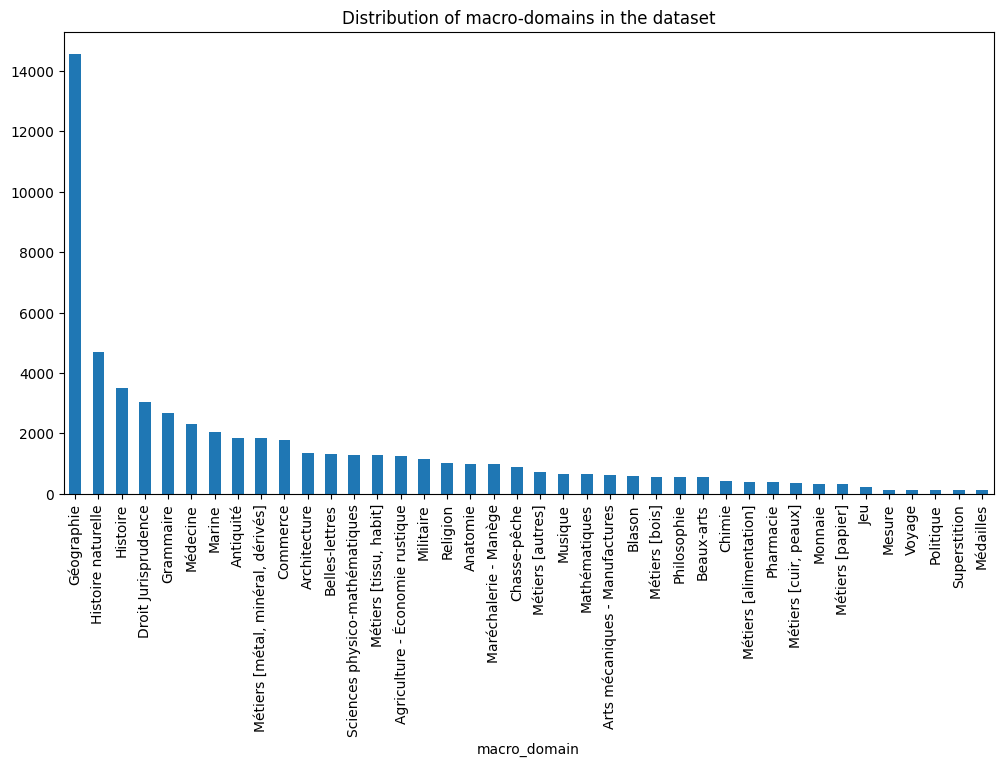

In [12]:
df['macro_domain'].value_counts().plot(kind='bar', figsize=(12,6), title='Distribution of macro-domains in the dataset')

In [13]:
df_eval = df[df['macro_domain'].notna()]

In [14]:
df_eval['macro_domain'].unique()

array(['Grammaire', 'Belles-lettres', 'Histoire', 'Chimie', 'Médecine',
       'Blason', 'Mathématiques', 'Chasse-pêche', 'Anatomie',
       'Droit Jurisprudence', 'Métiers [bois]', 'Métiers [tissu, habit]',
       'Commerce', 'Militaire', 'Philosophie', 'Antiquité',
       'Sciences physico-mathématiques', 'Métiers [autres]', 'Religion',
       'Architecture', 'Monnaie', 'Géographie', 'Beaux-arts', 'Musique',
       'Marine', 'Pharmacie', 'Agriculture - Économie rustique',
       'Métiers [métal, minéral, dérivés]', 'Histoire naturelle', 'Jeu',
       'Arts mécaniques - Manufactures', 'Métiers [papier]',
       'Superstition', 'Maréchalerie - Manège', 'Métiers [alimentation]',
       'Métiers [cuir, peaux]', 'Mesure', 'Politique', 'Voyage',
       'Médailles'], dtype=object)

In [15]:
set(df_eval['macro_domain'].unique()) | set(df_eval['predicted_label'].unique())

{'Agriculture - Économie rustique',
 'Anatomie',
 'Antiquité',
 'Architecture',
 'Arts mécaniques - Manufactures',
 'Beaux-arts',
 'Belles-lettres',
 'Blason',
 'Chasse-pêche',
 'Chimie',
 'Commerce',
 'Droit Jurisprudence',
 'Grammaire',
 'Géographie',
 'Histoire',
 'Histoire naturelle',
 'Jeu',
 'Marine',
 'Maréchalerie - Manège',
 'Mathématiques',
 'Mesure',
 'Militaire',
 'Monnaie',
 'Musique',
 'Médailles',
 'Médecine',
 'Métiers [alimentation]',
 'Métiers [autres]',
 'Métiers [bois]',
 'Métiers [cuir, peaux]',
 'Métiers [métal, minéral, dérivés]',
 'Métiers [papier]',
 'Métiers [tissu, habit]',
 'Pharmacie',
 'Philosophie',
 'Politique',
 'Religion',
 'Sciences physico-mathématiques',
 'Superstition',
 'Voyage'}


Classification Report :

                                   precision    recall  f1-score   support

  Agriculture - Économie rustique       0.98      0.96      0.97      1263
                         Anatomie       0.99      1.00      0.99       979
                        Antiquité       0.99      0.99      0.99      1854
                     Architecture       0.98      0.99      0.98      1332
   Arts mécaniques - Manufactures       0.92      0.93      0.92       624
                       Beaux-arts       0.98      0.83      0.90       539
                   Belles-lettres       0.98      0.99      0.99      1317
                           Blason       1.00      0.99      1.00       576
                     Chasse-pêche       0.98      0.99      0.99       886
                           Chimie       0.99      0.99      0.99       413
                         Commerce       0.98      1.00      0.99      1787
              Droit Jurisprudence       1.00      1.00      1.00      303

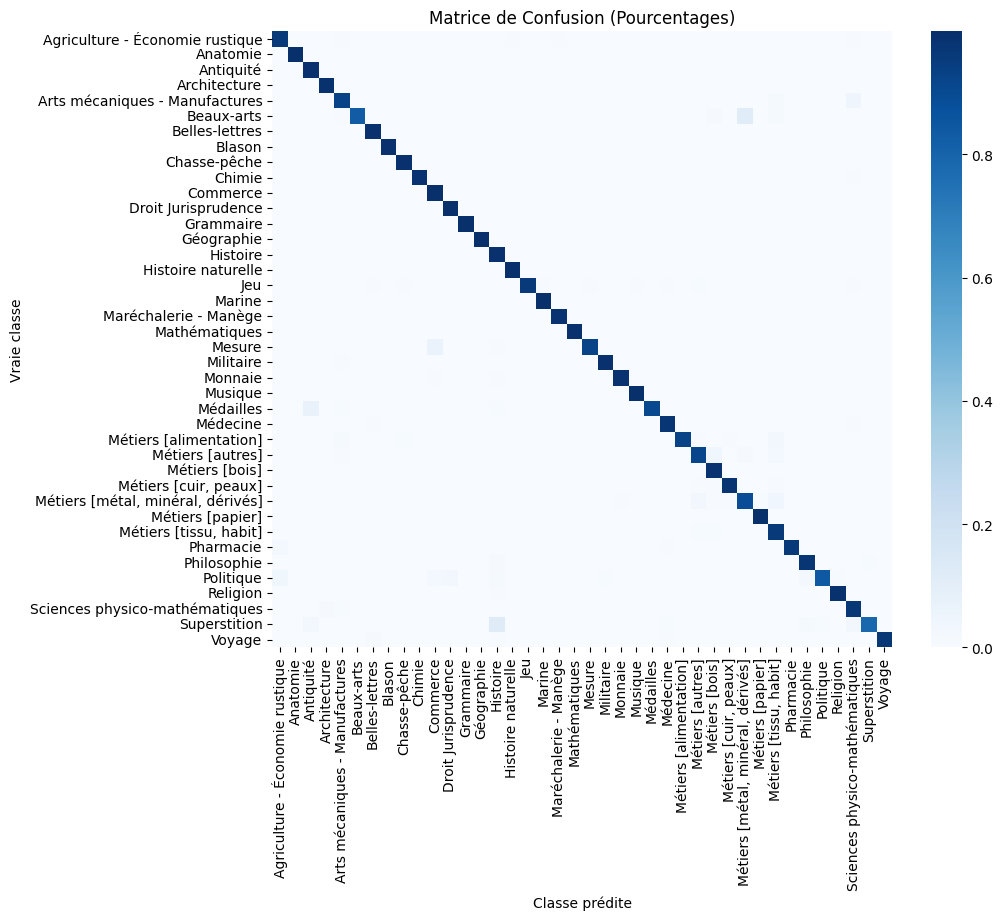

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = df_eval['macro_domain']
y_pred = df_eval['predicted_label']

class_names = sorted(list(df_eval['macro_domain'].unique()))

report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report :\n")
print(report)

cm = confusion_matrix(y_true, y_pred)

# 1. Normalisation de la matrice (chaque ligne totalise 100%)
# On utilise np.nan_to_num pour éviter les erreurs si une classe n'a aucun échantillon
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = np.nan_to_num(cm_percent)

# 2. Affichage graphique
plt.figure(figsize=(10, 8))

# annot=True affiche les valeurs
# fmt='.2%' formate les nombres en pourcentages avec 2 décimales
sns.heatmap(cm_percent, annot=False, fmt='.2%', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion (Pourcentages)')
plt.savefig(dirpath+"confusion_matrix_macro_domains_DUFLT.png")
plt.show()

# save report to a csv file
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(dirpath+"classification_report_macro_domains_EDdA.csv", index=True)

In [17]:
df['artfl_domain'] = df['artfl_domain'].fillna('')
df[df['artfl_domain'].str.contains(' \| ')]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/var/folders/qm/v_b1md29221_cnpcxf5qc43c0000gn/T/ipykernel_897/453113369.py:2: SyntaxWarning: invalid escape sequence '\|'
  df[df['artfl_domain'].str.contains(' \| ')]


,book,volume,numero,head,author,artfl_domain,text,predicted_label,macro_domain
236,EDdA,1,281,Abrevoirs,Blondel,Maçonnerie | Architecture,"Abrevoirs, (terme de Maçonnerie ou d'Archit.) ...",Architecture,Architecture
473,EDdA,1,545,ACERER,unsigned,Serrurerie | Taillanderie,"ACERER, v. adj. (Serrurerie & Taillanderie) c'...","Métiers [métal, minéral, dérivés]","Métiers [métal, minéral, dérivés]"
478,EDdA,1,551,ACERURE,unsigned,Serrurerie | Taillanderie,"ACERURE, s. f. (Serrurerie & Taillanderie.) On...","Métiers [métal, minéral, dérivés]","Métiers [métal, minéral, dérivés]"
479,EDdA,1,552,ACESTIDES,Diderot,Histoire naturelle | Minéralogie ancienne,"* ACESTIDES, s. f. (Hist. nat. & Minéralog. an...",Histoire naturelle,NaN
482,EDdA,1,555,ACHEIROPOEETE,Diderot,Histoire moderne | Théologie,"* ACHEIROPOEETE, (Théol. & Hist. mod.) qui n'e...",Religion,NaN
...,...,...,...,...,...,...,...,...,...
71074,EDdA,17,3120,CHOLON ou CHOLUS,d'Holbach,Histoire naturelle | Lithologie,"CHOLON ou CHOLUS, (Hist. nat. Lithol.) nom que...",Histoire naturelle,Histoire naturelle
71096,EDdA,17,3142,DISPENSE,Jaucourt,Droit naturel | Droit politique,"DISPENSE, s. f. (Droit natur. & polit.) privil...",Droit Jurisprudence,Droit Jurisprudence
71111,EDdA,17,3157,FORTUNE,unsigned,Inscription | Médailles | Poésie,"FORTUNE, (Inscript. Médailles, Poésie.) les mé...",Médailles,NaN
71142,EDdA,17,3188,IDOLATRIE,unsigned,Philosophie | Théologie,"IDOLATRIE, s. f. (Philos. & Théolog.) l'idolat...",Religion,NaN
